# **1. Perkenalan Dataset**


1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari *Kaggle*.
2. **Link Dataset**:
   https://www.kaggle.com/datasets/gauravtopre/bank-customer-churn-dataset
3. **Informasi Umum**:
   Dataset ini berisi data nasabah bank dan digunakan untuk memprediksi apakah seorang nasabah akan berhenti menggunakan layanan bank atau tidak. Target prediksi berada pada kolom `churn`.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
# Install Kaggle
!pip -q install kaggle
!pip -q install kagglehub
!pip -q install numpy pandas matplotlib seaborn scikit-learn


In [2]:
# Import libraries
import kagglehub

import os
import shutil
import zipfile
import random
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler

pd.set_option("display.max_columns", None)
sns.set(style="whitegrid")


/home/wervyan/.venvs/vscode/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [3]:
# Download Dataset

# Download latest version
path = kagglehub.dataset_download("gauravtopre/bank-customer-churn-dataset")

print("Path to dataset files:", path)

Path to dataset files: /home/wervyan/.cache/kagglehub/datasets/gauravtopre/bank-customer-churn-dataset/versions/1


In [4]:
# Download dataset dari Kaggle
!kaggle datasets download -d gauravtopre/bank-customer-churn-dataset -p . --force

# Extract dataset
zip_path = './bank-customer-churn-dataset.zip'
extract_dir = './bank_customer_churn_raw'

os.makedirs(extract_dir, exist_ok=True)
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("Dataset berhasil diunduh dan diekstrak ke:", extract_dir)

Dataset URL: https://www.kaggle.com/datasets/gauravtopre/bank-customer-churn-dataset
License(s): other
100%|████████████████████████████████████████| 187k/187k [00:00<00:00, 457kB/s]

Dataset berhasil diunduh dan diekstrak ke: ./bank_customer_churn_raw


In [5]:
raw_path = f"{extract_dir}/Bank Customer Churn Prediction.csv"
print("Dataset path:", raw_path)

df = pd.read_csv(raw_path)
df.head()

Dataset path: ./bank_customer_churn_raw/Bank Customer Churn Prediction.csv


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [6]:
# Menampilkan dimensi dataset
print("Jumlah baris dan kolom:", df.shape)

Jumlah baris dan kolom: (10000, 12)


In [7]:
# Menampilkan informasi tipe data dan jumlah nilai non-null
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  str    
 3   gender            10000 non-null  str    
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), str(2)
memory usage: 937.6 KB


In [8]:
# Menampilkan statistik deskriptif fitur numerik
df.describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [9]:
# Menampilkan list kolom
df.columns.tolist()

['customer_id',
 'credit_score',
 'country',
 'gender',
 'age',
 'tenure',
 'balance',
 'products_number',
 'credit_card',
 'active_member',
 'estimated_salary',
 'churn']

In [10]:
# Menampilkan jumlah missing value pada setiap kolom
df.isnull().sum()

customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

In [11]:
# Mengecek jumlah data duplikat
df.duplicated().sum()

np.int64(0)

In [12]:
# Distribusi target churn
df["churn"].value_counts()

churn
0    7963
1    2037
Name: count, dtype: int64

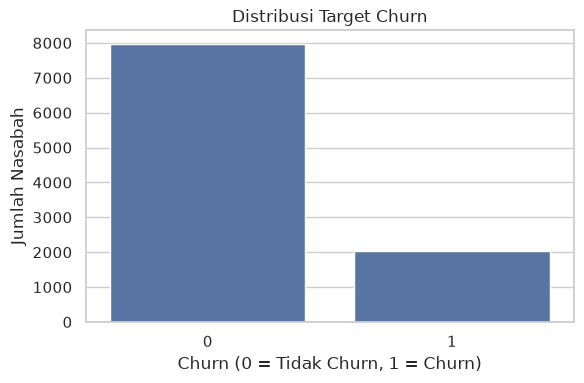

In [13]:
# Plot Churn
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="churn")
plt.title("Distribusi Target Churn")
plt.xlabel("Churn (0 = Tidak Churn, 1 = Churn)")
plt.ylabel("Jumlah Nasabah")
plt.tight_layout()
plt.show()

/tmp/ipykernel_27169/3780452432.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=["object"]).columns.tolist()


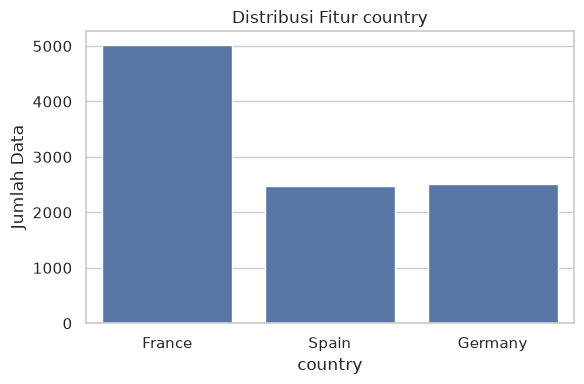

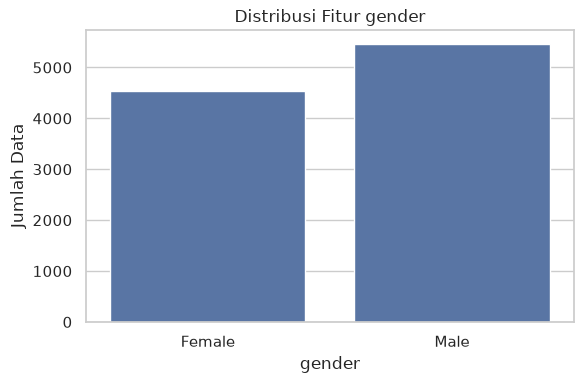

In [14]:
# Distribusi fitur kategorikal
categorical_columns = df.select_dtypes(include=["object"]).columns.tolist()

for col in categorical_columns:
  plt.figure(figsize=(6,4))
  sns.countplot(data=df, x=col)
  plt.title(f"Distribusi Fitur {col}")
  plt.xlabel(col)
  plt.ylabel("Jumlah Data")
  plt.tight_layout()
  plt.show()

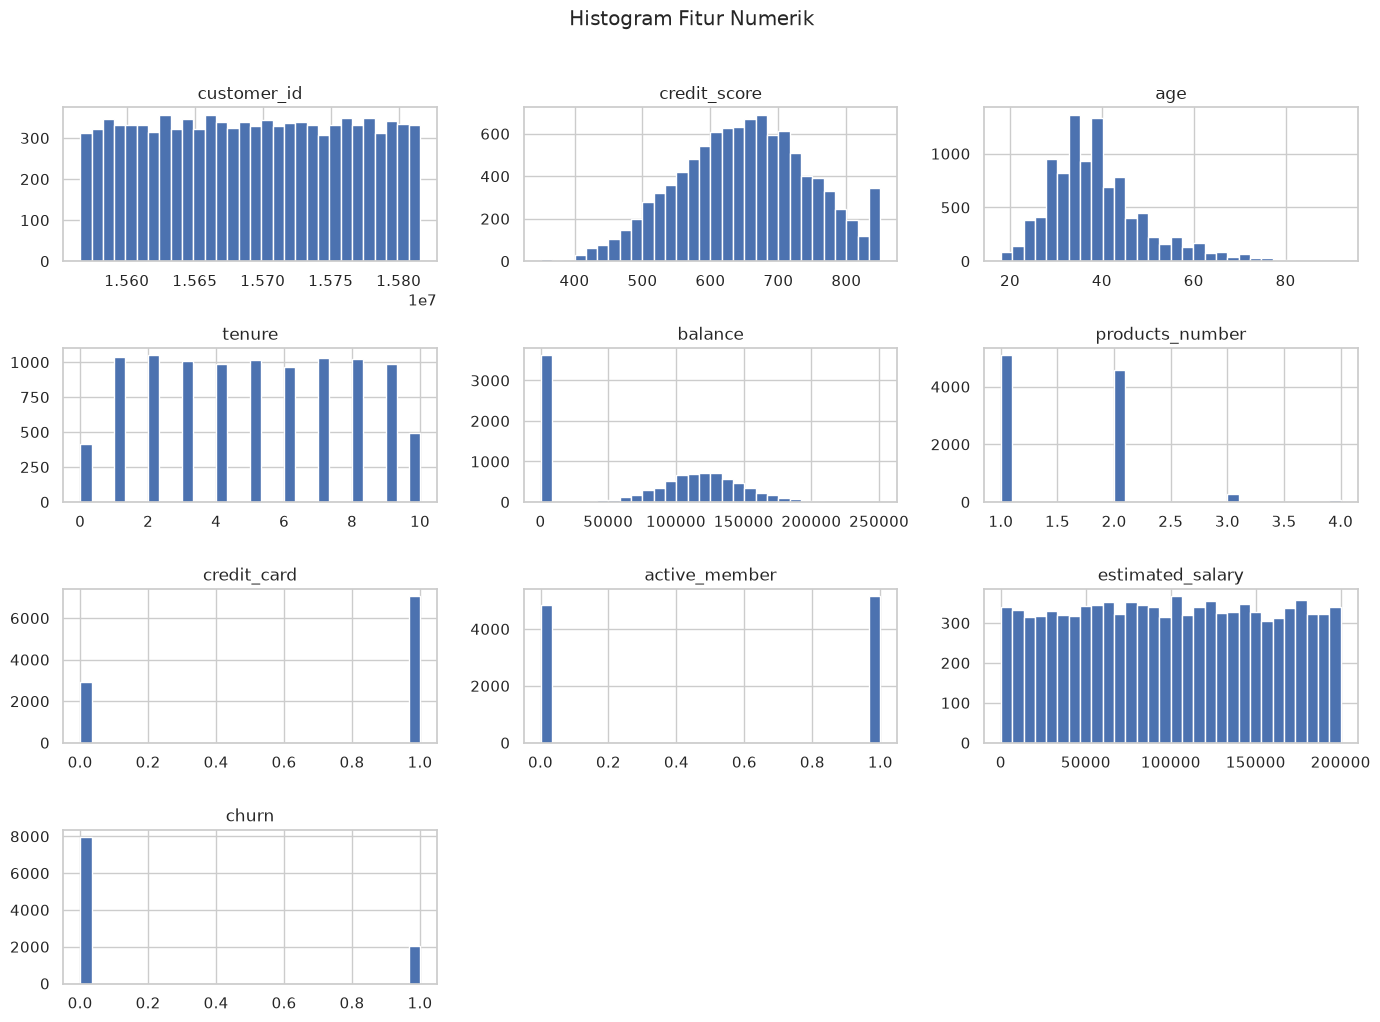

In [15]:
# Histogram fitur numerik
numeric_columns = df.select_dtypes(include=["int64","float64"]).columns.tolist()

df[numeric_columns].hist(figsize=(14,10), bins=30)
plt.suptitle("Histogram Fitur Numerik", y=1.02)
plt.tight_layout()
plt.show()

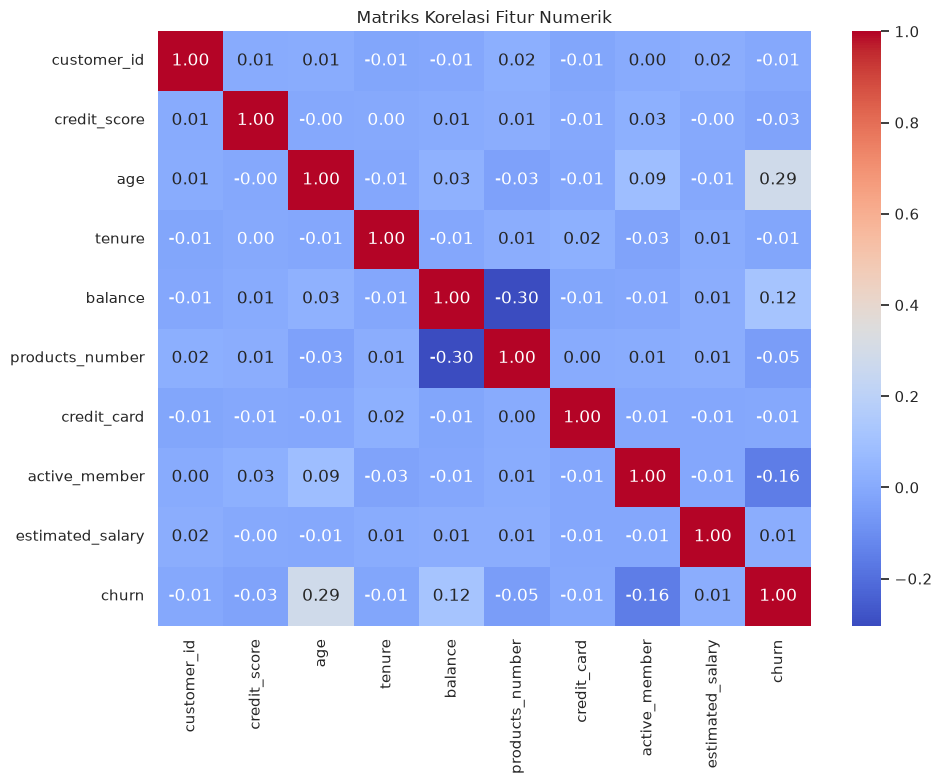

In [16]:
# Matriks korelasi fitur numerik
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriks Korelasi Fitur Numerik")
plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus kolom identifier `customer_id` karena tidak relevan untuk proses pelatihan
2. Menghapus atau Menangani Data Kosong (Missing Values)
3. Menghapus Data Duplikat
4. Encoding Data Kategorikal
5. Normalisasi atau Standarisasi Fitur
6. Deteksi dan Penanganan Outlier
7. Menyimpan dataset hasil preprocessing ke file CSV

In [17]:
# Section ini akan dikonversi untuk otomasi
# Membuat salinan dataset agar data mentah tetap aman
df_clean = df.copy()

# Menghapus kolom identifer yang tidak digunakan untuk pelatihan model
if "customer_id" in df_clean.columns:
  df_clean = df_clean.drop(columns=["customer_id"])

print("Kolom setelah customer_id dihapus:")
print(df_clean.columns.tolist())

# Menangani missing value dan data duplikat
df_clean = df_clean.dropna()
df_clean = df_clean.drop_duplicates()

print("Ukuran data setelah drop missing value dand uplikat:", df_clean.shape)

# Memastikan target tersedia
target_col = "churn"
if target_col not in df_clean.columns:
  raise ValueError(f"Kolom target '{target_col}' tidak ditemukan.")

# Identifikasi fitur kategorical
categorical_cols = df_clean.select_dtypes(include=["object"]).columns.tolist()
print("Kolom kategorikal:", categorical_cols)

# Encoding fitur kategorikal menggunakan LabelEncoder
label_encoders = {}

for col in categorical_cols:
  encoder = LabelEncoder()
  df_clean[col] = encoder.fit_transform(df_clean[col])
  label_encoders[col] = encoder
  print(f"Mapping {col}:", dict(zip(encoder.classes_, encoder.transform(encoder.classes_))))

df_clean.head()

# MEmisahkan fitur dan target
X = df_clean.drop(columns=[target_col])
y = df_clean[target_col]

print("Jumlah fitur:", X.shape[1])
print("Nama fitur:", X.columns.tolist())

# Standardisasi seluruh fitur numerik agar berada pada skala yang sebanding
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns,
    index=X.index
)

# Menggabungkan fitur hasil preprocessing dengan target
df_preprocessed = X_scaled.copy()
df_preprocessed[target_col] = y.values

# Pemeriksaan akhir dataset hasil preprocessing
print("Ukuran dataset preprocessed:", df_preprocessed.shape)
print("Total missing values:", df_preprocessed.isnull().sum().sum())
print("Duplikasi total:", df_preprocessed.duplicated().sum())

df_preprocessed.describe()

# Menyimpan dataset hasil preprocessing
output_dir = Path("bank_customer_churn_preprocessing")
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / "bank_customer_churn_preprocessing.csv"
df_preprocessed.to_csv(output_path, index=False)

print("Dataset hasil preprocessing berhasil disimpan di:", output_path)

Kolom setelah customer_id dihapus:
['credit_score', 'country', 'gender', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'churn']
Ukuran data setelah drop missing value dand uplikat: (10000, 11)
Kolom kategorikal: ['country', 'gender']
Mapping country: {'France': np.int64(0), 'Germany': np.int64(1), 'Spain': np.int64(2)}
Mapping gender: {'Female': np.int64(0), 'Male': np.int64(1)}
Jumlah fitur: 10
Nama fitur: ['credit_score', 'country', 'gender', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary']
Ukuran dataset preprocessed: (10000, 11)
Total missing values: 0
Duplikasi total: 0
Dataset hasil preprocessing berhasil disimpan di: bank_customer_churn_preprocessing/bank_customer_churn_preprocessing.csv


/tmp/ipykernel_27169/2553431288.py:24: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_clean.select_dtypes(include=["object"]).columns.tolist()


In [18]:
print("Cuplikan X terstandardisasi:")
X_scaled.head()

Cuplikan X terstandardisasi:


,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary
0,-0.326221,-0.901886,-1.095988,0.293517,-1.041760,-1.225848,-0.911583,0.646092,0.970243,0.021886
1,-0.440036,1.515067,-1.095988,0.198164,-1.387538,0.117350,-0.911583,-1.547768,0.970243,0.216534
2,-1.536794,-0.901886,-1.095988,0.293517,1.032908,1.333053,2.527057,0.646092,-1.030670,0.240687
3,0.501521,-0.901886,-1.095988,0.007457,-1.387538,-1.225848,0.807737,-1.547768,-1.030670,-0.108918
4,2.063884,1.515067,-1.095988,0.388871,-1.041760,0.785728,-0.911583,0.646092,0.970243,-0.365276


In [19]:
print("Cuplikan preprocessed dataset:")
df_preprocessed.head()

Cuplikan preprocessed dataset:


,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,-0.326221,-0.901886,-1.095988,0.293517,-1.041760,-1.225848,-0.911583,0.646092,0.970243,0.021886,1
1,-0.440036,1.515067,-1.095988,0.198164,-1.387538,0.117350,-0.911583,-1.547768,0.970243,0.216534,0
2,-1.536794,-0.901886,-1.095988,0.293517,1.032908,1.333053,2.527057,0.646092,-1.030670,0.240687,1
3,0.501521,-0.901886,-1.095988,0.007457,-1.387538,-1.225848,0.807737,-1.547768,-1.030670,-0.108918,0
4,2.063884,1.515067,-1.095988,0.388871,-1.041760,0.785728,-0.911583,0.646092,0.970243,-0.365276,0
